In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
# ========================
# Cargar dataset
# ========================

df = pd.read_csv("../data/interim/hotel_bookings_fe.csv")

print(df.shape)

df.head()

(119204, 65)


,is_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,required_car_parking_spaces,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
0,0,2015,27,1,0,0,0,3,0,0,...,False,True,False,False,False,False,False,False,False,False
1,0,2015,27,1,0,0,0,4,0,0,...,False,True,False,False,False,False,False,False,False,False
2,0,2015,27,1,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False
3,0,2015,27,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,0,2015,27,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [17]:
# ========================
# Variables predictoras
# ========================

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

print(X.shape)
print(y.shape)

(119204, 64)
(119204,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_test.shape)

(23841, 64)


In [19]:
# ========================
# Cargar modelo final
# ========================

model = joblib.load("../models/final_model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [20]:
# ========================
# Predicciones
# ========================

y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:,1]

print(y_pred[:10])
print(y_proba[:10])

[1 0 0 1 1 0 0 1 0 0]
[0.99999976 0.10317802 0.00806252 0.87073404 0.9896438  0.03032959
 0.42867237 0.9999863  0.20415018 0.05525214]


In [21]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8673713350950044
Recall: 0.7753139495418033
F1: 0.8125444628883092


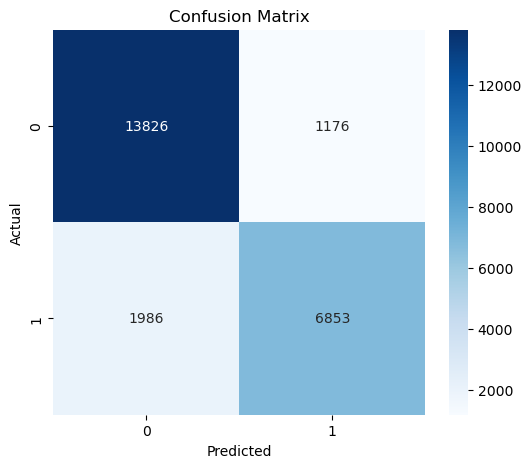

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

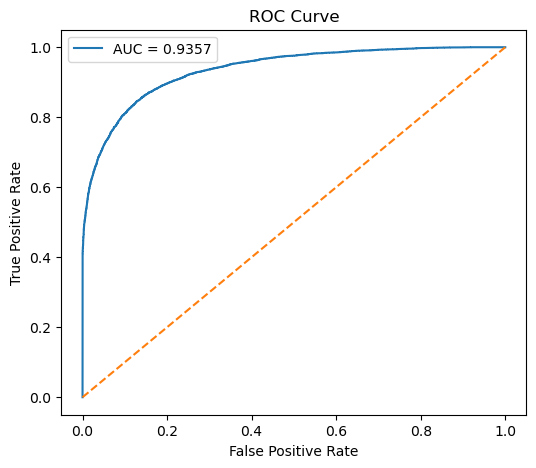

In [23]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [13]:
import shap

In [24]:
clf = model.named_steps["clf"]

print(type(clf))

<class 'xgboost.sklearn.XGBClassifier'>


In [25]:
explainer = shap.TreeExplainer(clf)

In [26]:
X_sample = X_test.sample(500, random_state=42)

In [27]:
shap_values = explainer.shap_values(X_sample)

In [29]:
print(shap_values.types)

AttributeError: 'numpy.ndarray' object has no attribute 'types'

In [23]:
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.savefig(
    "../dashboard/assets/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

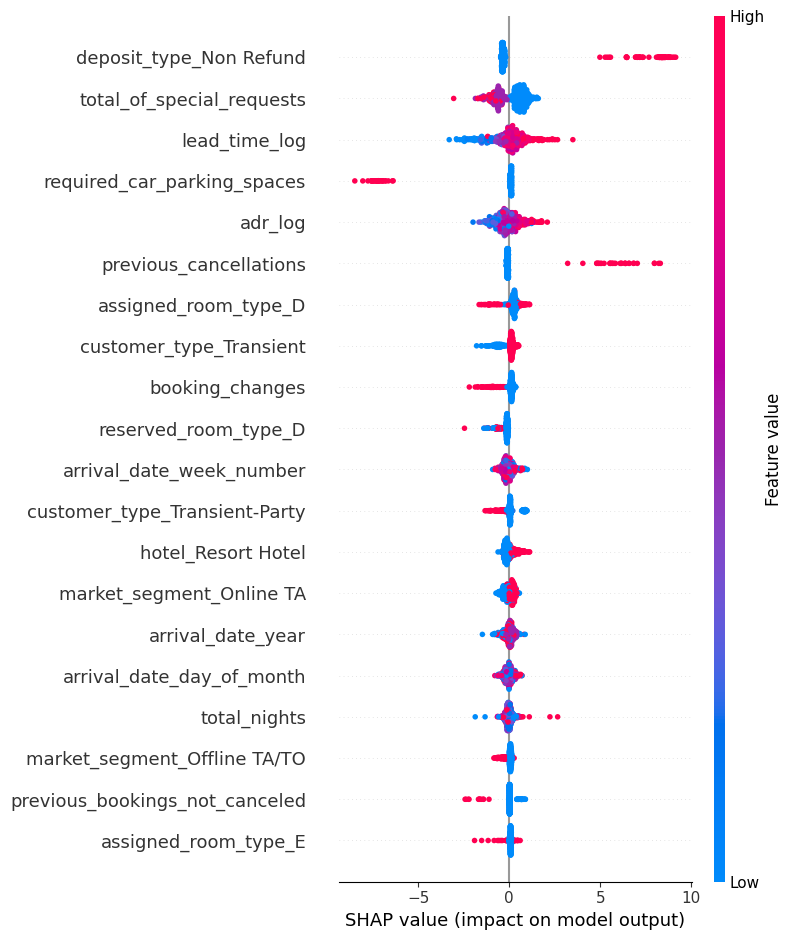

In [19]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [21]:
# Guardar sample para Streamlit

X_test.sample(100).to_csv(
    "../dashboard/assets/sample_input.csv",
    index=False
)

print("CSV guardado correctamente")

CSV guardado correctamente
